## Load data

In [1]:
import shap 
import numpy as np
import matplotlib.pyplot as plt
from dataAnalysis.data.Filter import Filter
import pandas as pd
from dataAnalysis.Constants import *
from dataAnalysis.DataAnalysis import DataAnalysis
import os

In [2]:
data = pd.read_csv(r"extdata/sbcdata.csv", header=0)
data_analysis = DataAnalysis(data)

/home/dwalke/git/sbc_app/dataAnalysis/data/Filter.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Label'] = self.data['Diagnosis']
/home/dwalke/git/sbc_app/dataAnalysis/data/Filter.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Label'] = self.data['Diagnosis']
/home/dwalke/git/sbc_app/dataAnalysis/data/Filter.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

In [3]:
from sklearn.model_selection import train_test_split
y_train = data_analysis.get_y_train()
X_train = data_analysis.get_X_train()

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

y_test = data_analysis.get_y_test()
X_test = data_analysis.get_X_test()

y_gw_test = data_analysis.get_y_gw()
X_gw_test = data_analysis.get_X_gw()

## Pred proba exporter

In [9]:
baseline_pred_probas = pd.DataFrame()

baseline_pred_probas["y"] = y_test

## Utils functions

In [4]:
from sklearn.metrics import roc_curve
from numpy import sqrt, argmax
import numpy as np
def get_best_threshold(model):
    global X_val, y_val
    pred_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = roc_curve(y_test, pred_proba)
    gmeans = sqrt(tpr * (1-fpr))
    ix = argmax(gmeans)
    return model.__class__.__name__, round(thresholds[ix], 4) 

In [5]:
def print_and_export_shap_overview(shap_vals, title:str, plt_title:str):

    samples_shap_vals = shap_vals[:, :7]
    time_shap_vals = shap_vals[:, 7:]

    plt.rcParams.update({'font.size': 22})
    fig =  plt.figure(figsize=(30, 15))
    gs = fig.add_gridspec(2, 2)
    FEATURES[1] = "Sex"
    
    ax = fig.add_subplot(gs[:, :])
    plt.sca(ax)
    shap.summary_plot(shap_vals, plot_type="bar", show=False,  class_inds='original', feature_names = FEATURES)
    ax.set_xlabel("Mean |shap values|")
    ax.set_title(plt_title)
    ax.grid()
    plt.tight_layout()
    plt.show()
    fig.savefig(f"{title}.png", dpi = 300, bbox_inches='tight',format="png")

## Metrics definition

In [6]:
from dataAnalysis.Metrics import Evaluation

evaluation = Evaluation(y_test, y_gw_test, X_test, X_gw_test)

/home/dwalke/.local/lib/python3.10/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/home/dwalke/.local/lib/python3.10/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/home/dwalke/.local/lib/python3.10/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [7]:
from sklearn.metrics import roc_curve, confusion_matrix
def get_sensitvity_at_specifity(model, X, y, desired_specificity = .8):
    y_pred_proba = model.predict_proba(X)[:, 1]
    fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
    
    desired_specificity = 0.8
    desired_fpr = 1 - desired_specificity
    
    for i, fp_rate in enumerate(fpr):
        if fp_rate >= desired_fpr:
            threshold = thresholds[i]
            break
    
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    print(tn / (tn + fp))
    sensitivity = tp / (tp + fn)
    return sensitivity

## Logistic regression

4.910404920578003
         Name      MCC  F1-Micro  F1-Macro  F1-Binary     AUROC     AUPRC
0     Leipzig  0.04438  0.776029  0.441203   0.008652  0.837299  0.009562
1  Greifswald  0.02219  0.589513  0.372618   0.003734  0.755741  0.004316


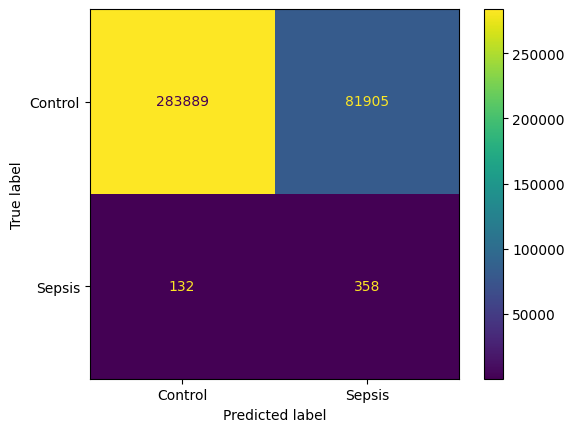

In [10]:
from sklearn.linear_model import LogisticRegression
import time
start = time.time()
logistic_regression = LogisticRegression(random_state=0, solver="liblinear", class_weight="balanced")
logistic_regression.fit(X_train, y_train)
print(time.time() -start)
print(evaluation.get_df_metrics(logistic_regression))
evaluation.plot_confusion_matrix(logistic_regression)

In [11]:
model = logistic_regression
get_sensitvity_at_specifity(model, X_test, y_test), get_sensitvity_at_specifity(model, X_gw_test, y_gw_test)
baseline_pred_probas[logistic_regression.__class__.__name__] = logistic_regression.predict_proba(X_test)[:, 1]

0.7963908648036874
0.7975088488194338


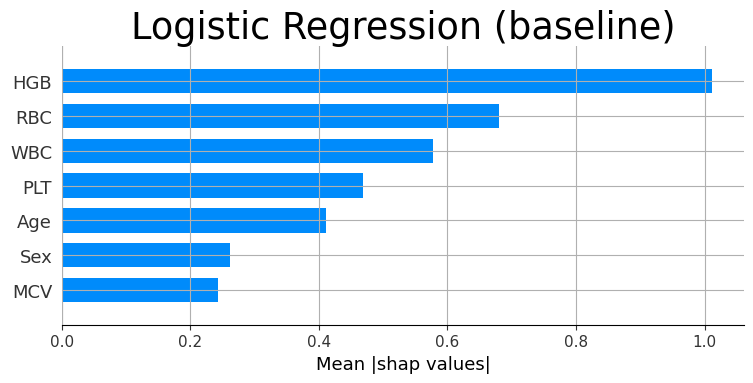

In [63]:
explainer = shap.LinearExplainer(logistic_regression, X_test)
lr_test_shap_vals = None
if os.path.exists('lr_test_shap_vals.npy'):
    lr_test_shap_vals = np.load('lr_test_shap_vals.npy')
else:
    lr_test_shap_vals = explainer.shap_values(X_test)
    np.save('lr_test_shap_vals.npy', lr_test_shap_vals)
print_and_export_shap_overview(lr_test_shap_vals, "lr_baseline", "Logistic Regression (baseline)")

## Decision Tree

2.782663106918335
         Name       MCC  F1-Micro  F1-Macro  F1-Binary     AUROC     AUPRC
0     Leipzig  0.043102  0.718623  0.421867   0.007664  0.843035  0.009857
1  Greifswald  0.028284  0.634135  0.390150   0.004410  0.779033  0.003830


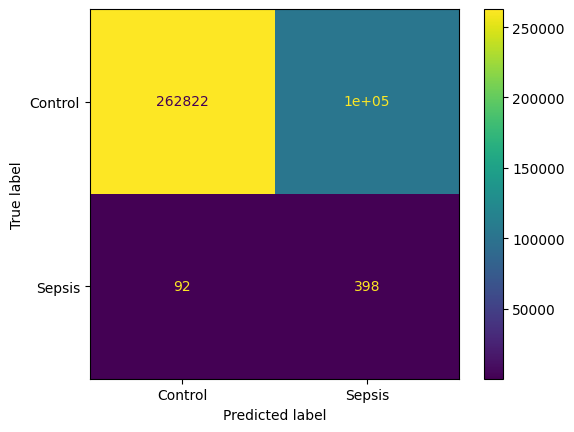

In [13]:
from sklearn.tree import DecisionTreeClassifier
import time
start = time.time()
decision_tree = DecisionTreeClassifier(random_state=42, max_features=6, min_samples_leaf=0.005,
                       min_samples_split=0.03, class_weight="balanced")
decision_tree.fit(X_train, y_train)
print(time.time() -start)
print(evaluation.get_df_metrics(decision_tree))
evaluation.plot_confusion_matrix(decision_tree)

In [14]:
model = decision_tree
get_sensitvity_at_specifity(model, X_test, y_test), get_sensitvity_at_specifity(model, X_gw_test, y_gw_test)
baseline_pred_probas[model.__class__.__name__] = model.predict_proba(X_test)[:, 1]

0.7856006386108028
0.7929661882553487


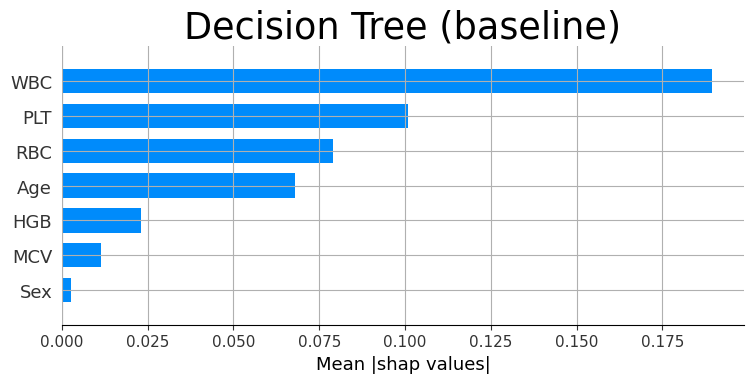

In [64]:
explainer = shap.TreeExplainer(decision_tree)
dt_test_shap_vals = None
if os.path.exists('dt_test_shap_vals.npy'):
    dt_test_shap_vals = np.load('dt_test_shap_vals.npy')
else:
    dt_test_shap_vals = explainer.shap_values(X_test)[:, :, -1]
    np.save('dt_test_shap_vals.npy', dt_test_shap_vals)
print_and_export_shap_overview(dt_test_shap_vals, "dt_baseline", "Decision Tree (baseline)")

## Random Forest

17.335118293762207
         Name       MCC  F1-Micro  F1-Macro  F1-Binary     AUROC     AUPRC
0     Leipzig  0.061250  0.890670  0.478684   0.015246  0.869492  0.017609
1  Greifswald  0.037536  0.843744  0.461382   0.007568  0.816620  0.005520
[0.12354404 0.01285918 0.05676561 0.52311777 0.07617018 0.06276627
 0.14477696]


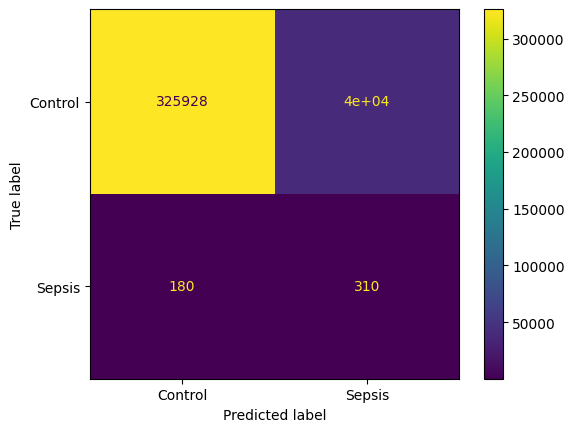

In [15]:
from sklearn.ensemble import RandomForestClassifier
import time
start = time.time()
random_forest = RandomForestClassifier(class_weight={0: 0.0025, 1: 1}, max_leaf_nodes=79,
                           min_samples_leaf=0.0001,
                           min_samples_split=0.0055,
                           n_estimators=500, random_state=42, n_jobs=-1)
random_forest.fit(X_train, y_train)
print(time.time() -start)
print(evaluation.get_df_metrics(random_forest))
evaluation.plot_confusion_matrix(random_forest)
print(random_forest.feature_importances_)

In [16]:
model = random_forest
get_sensitvity_at_specifity(model, X_test, y_test), get_sensitvity_at_specifity(model, X_gw_test, y_gw_test)
baseline_pred_probas[model.__class__.__name__] = model.predict_proba(X_test)[:, 1]

0.7968446721378699
0.7968918878776315


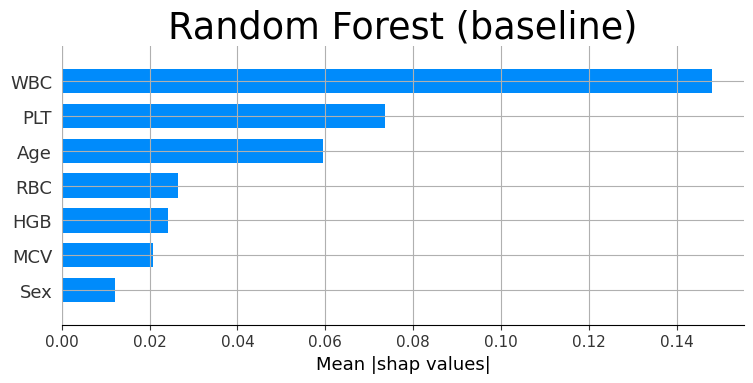

In [65]:
explainer = shap.TreeExplainer(random_forest)
rf_test_shap_vals = None
if os.path.exists('rf_test_shap_vals.npy'):
    rf_test_shap_vals = np.load('rf_test_shap_vals.npy')
else:
    rf_test_shap_vals = explainer.shap_values(X_test)[:, :, -1]
    np.save('rf_test_shap_vals.npy', rf_test_shap_vals)
print_and_export_shap_overview(rf_test_shap_vals, "rf_baseline", "Random Forest (baseline)")

## XG Boost

/home/dwalke/.local/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [10:27:49] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


2.324796199798584


/home/dwalke/.local/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [10:27:51] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/home/dwalke/.local/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [10:27:51] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


         Name       MCC  F1-Micro  F1-Macro  F1-Binary     AUROC     AUPRC
0     Leipzig  0.078099  0.981659  0.516335   0.041928  0.869747  0.019786
1  Greifswald  0.042958  0.960546  0.497569   0.015269  0.802613  0.007120


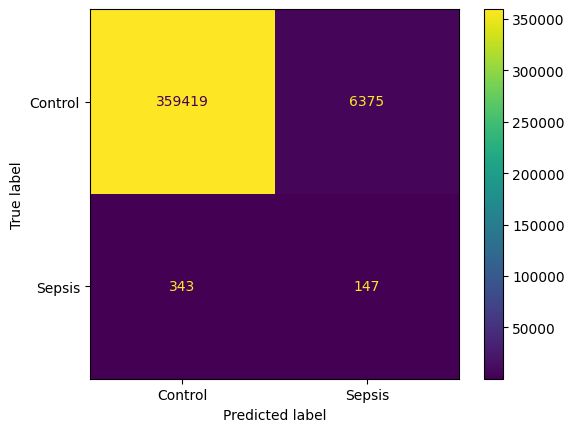

In [17]:
from xgboost import XGBClassifier
import time
start = time.time()

xgb_classifier = XGBClassifier(tree_method='gpu_hist', 
                           scale_pos_weight = 70,
                           n_estimators=1000,
                           max_depth=2,
                           eta=0.1,
                           min_child_weight = 7,
                           max_delta_step= 7,
                           sampling_method= "uniform")
xgb_classifier.fit(X_train, y_train)
print(time.time() -start)
print(evaluation.get_df_metrics(xgb_classifier))
evaluation.plot_confusion_matrix(xgb_classifier)

In [18]:
model = xgb_classifier
get_sensitvity_at_specifity(model, X_test, y_test), get_sensitvity_at_specifity(model, X_gw_test, y_gw_test)
baseline_pred_probas[model.__class__.__name__] = model.predict_proba(X_test)[:, 1]

0.7989305456076371
0.7995173994410791


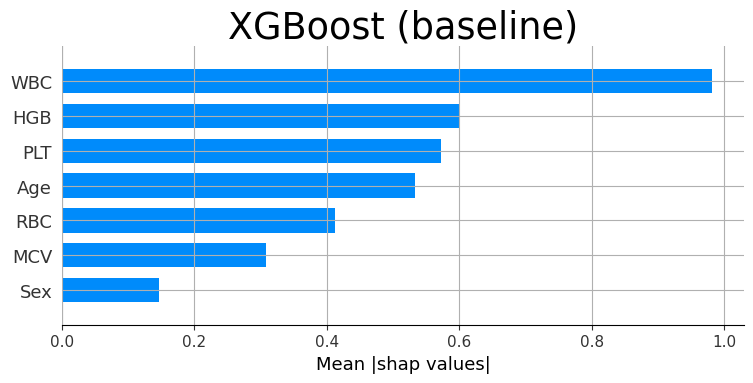

In [66]:
explainer = shap.TreeExplainer(xgb_classifier)
xgb_test_shap_vals = None
if os.path.exists('xgb_test_shap_vals.npy'):
    xgb_test_shap_vals = np.load('xgb_test_shap_vals.npy')
else:
    xgb_test_shap_vals = explainer.shap_values(X_test)
    np.save('xgb_test_shap_vals.npy', xgb_test_shap_vals)
print_and_export_shap_overview(xgb_test_shap_vals, "xgb_baseline", "XGBoost (baseline)")

In [19]:
baseline_pred_probas.to_csv("pred_probas_baseline.csv", index = False)